# Healthcare Insurance: Data Collection and Cleaning

## Objectives

- Document the dataset source and licence.
- Load and inspect the original data.
- Check missing values, duplicates, categories and numerical ranges.
- Investigate possible outliers.
- Apply justified cleaning transformations.
- Create age and BMI groups.
- Save a processed dataset for analysis.

## Inputs

- `data/raw/insurance.csv`

## Outputs

- `data/processed/insurance_clean.csv`

## Data source

The data was downloaded from the Healthcare Insurance dataset on Kaggle.
The dataset is published under the CC0 public-domain licence.

The original file is stored unchanged in `data/raw/`. Cleaning operations
will be applied to a copy, and the result will be stored in
`data/processed/`.

In [1]:
from pathlib import Path
import platform

import pandas as pd

project_root = Path.cwd()

if project_root.name == "jupyter_notebooks":
    project_root = project_root.parent

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "insurance.csv"
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "insurance_clean.csv"
)

print(f"Python version: {platform.python_version()}")
print(f"pandas version: {pd.__version__}")
print(f"Project root: {project_root}")

Python version: 3.12.8
pandas version: 2.1.1
Project root: /Users/ewa/Documents/vscode-projects/code-institute-2026/Healthcare-Insurance-Cost-Analysis


## Load the source data

Pandas is used to load the CSV file into a DataFrame. A DataFrame represents the data as rows and columns.

In [2]:
insurance_raw = pd.read_csv(raw_data_path)

print(
    f"The dataset contains {insurance_raw.shape[0]:,} rows "
    f"and {insurance_raw.shape[1]} columns."
)

insurance_raw.head()

The dataset contains 1,338 rows and 7 columns.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
insurance_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
insurance_raw.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
duplicate_count = insurance_raw.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 1


In [7]:
for column in ["sex", "smoker", "region"]:
    values = sorted(
        insurance_raw[column]
        .dropna()
        .unique()
    )

    print(f"{column}: {values}")

sex: ['female', 'male']
smoker: ['no', 'yes']
region: ['northeast', 'northwest', 'southeast', 'southwest']


## Initial quality findings

- The dataset contains **1338 rows and 7 columns**
- The dataset includes **3 categorical variables** ('sex', 'smoker', 'region') and **4 numerical variables** ('age', 'bmi', 'children', 'charges')
- All columns have the correct data types ('int64', 'float64', and 'object')
- The dataset contains no missing values
- The dataset contains 1 duplicate row
- The categorical values are:
    - **sex:** female, male
    - **smoker:** no, yes
    - **region:** northeast, northwest, southeast, southwest
- The numerical variables appear to have reasonable ranges:
    - **Age:** 18-64 years
    - **BMI:** approximately 15.96-53.13
    - **Children:** 0-5
    - **Charges:** approximately $1,121.87-$63,770.43
- No obvious data quality issues were indentified apart from the single duplicate record

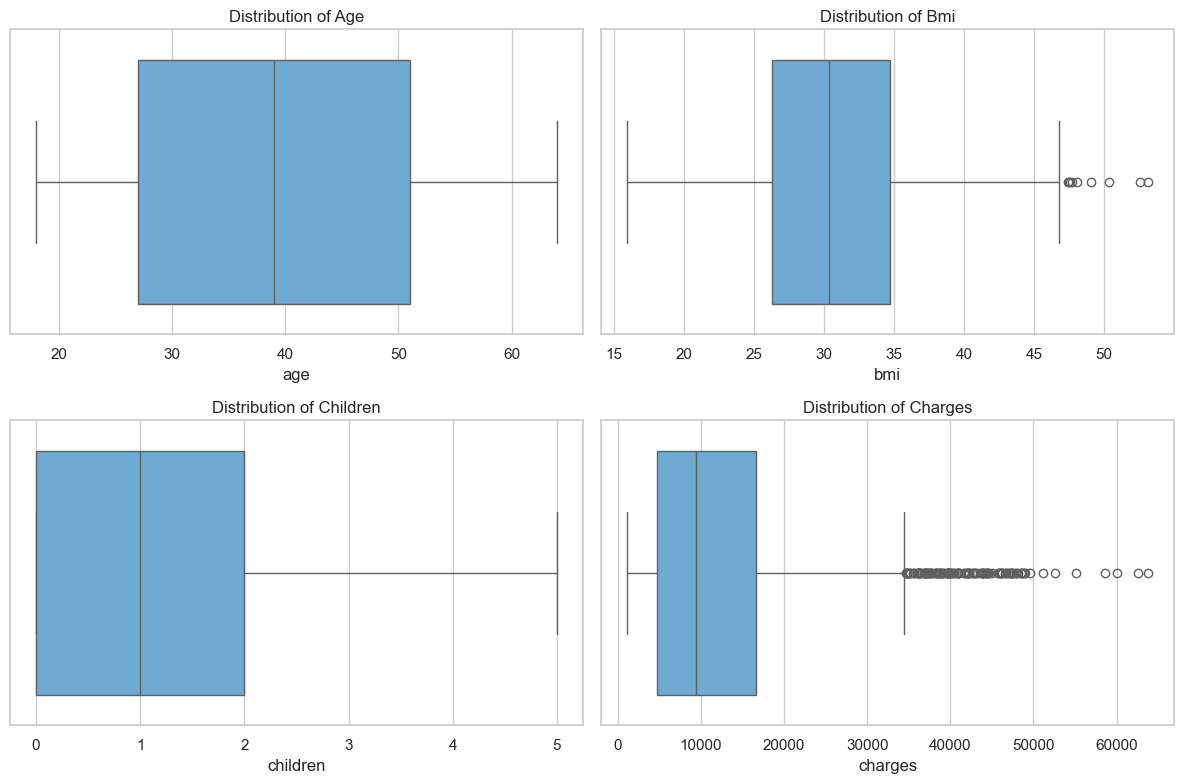

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

numerical_columns = [
    "age",
    "bmi",
    "children",
    "charges"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

for column, axis in zip(
    numerical_columns,
    axes.flatten()
):
    sns.boxplot(
        data=insurance_raw,
        x=column,
        color="#5DADE2",
        ax=axis
    )

    axis.set_title(
        f"Distribution of {column.title()}"
    )

plt.tight_layout()
plt.show()

## Outlier decision

The box plots identify observations that are statistically unusual, but this does not prove that the observations are incorrect.

High insurance charges may be genuine and are important to the business
question. Plausible observations will therefore be retained unless there is
evidence that they are data-entry errors.

## Cleaning decisions

The cleaning process will:

1. Work on a copy of the original data.
2. Standardise column names and category values.
3. Remove exact duplicate records.
4. Validate categories and plausible numerical ranges.
5. Retain plausible high-charge observations.

In [9]:
insurance_clean = insurance_raw.copy()

insurance_clean.columns = (
    insurance_clean.columns
    .str.strip()
    .str.lower()
)

categorical_columns = [
    "sex",
    "smoker",
    "region"
]

for column in categorical_columns:
    insurance_clean[column] = (
        insurance_clean[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

rows_before = len(insurance_clean)

insurance_clean = (
    insurance_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

rows_removed = (
    rows_before
    - len(insurance_clean)
)

print(f"Duplicate rows removed: {rows_removed}")
print(f"Rows remaining: {len(insurance_clean):,}")

Duplicate rows removed: 1
Rows remaining: 1,337


In [10]:
expected_columns = {
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region",
    "charges"
}

assert set(insurance_clean.columns) == expected_columns
assert insurance_clean.isna().sum().sum() == 0
assert insurance_clean.duplicated().sum() == 0

assert insurance_clean["age"].between(18, 120).all()
assert insurance_clean["bmi"].between(10, 70).all()
assert insurance_clean["children"].between(0, 20).all()
assert insurance_clean["charges"].ge(0).all()

assert set(insurance_clean["sex"]) <= {
    "female",
    "male"
}

assert set(insurance_clean["smoker"]) <= {
    "yes",
    "no"
}

assert set(insurance_clean["region"]) <= {
    "northeast",
    "northwest",
    "southeast",
    "southwest"
}

print("All validation checks passed.")

All validation checks passed.


## Create analysis features (Age and BMI)

In [11]:
insurance_clean["age_group"] = pd.cut(
    insurance_clean["age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64"
    ],
    right=False,
    include_lowest=True
)

In [12]:
insurance_clean["bmi_category"] = pd.cut(
    insurance_clean["bmi"],
    bins=[
        0,
        18.5,
        25,
        30,
        float("inf")
    ],
    labels=[
        "Underweight",
        "Healthy weight",
        "Overweight",
        "Obesity"
    ],
    right=False
)

In [13]:
insurance_clean[
    [
        "age",
        "age_group",
        "bmi",
        "bmi_category"
    ]
].head(10)

,age,age_group,bmi,bmi_category
0,19,18-24,27.900,Overweight
1,18,18-24,33.770,Obesity
2,28,25-34,33.000,Obesity
3,33,25-34,22.705,Healthy weight
4,32,25-34,28.880,Overweight
5,31,25-34,25.740,Overweight
6,46,45-54,33.440,Obesity
7,37,35-44,27.740,Overweight
8,37,35-44,29.830,Overweight
9,60,55-64,25.840,Overweight


In [14]:
insurance_clean[
    [
        "age_group",
        "bmi_category"
    ]
].isna().sum()

age_group       0
bmi_category    0
dtype: int64

Age and BMI groups were created to make descriptive comparisons easier to
communicate. The original continuous values were retained because grouping
removes detail and the continuous values are more suitable for modelling.

BMI categories are used descriptively and should not be interpreted as
medical diagnoses.

In [15]:
processed_data_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

insurance_clean.to_csv(
    processed_data_path,
    index=False
)

print(
    f"Processed data saved to: "
    f"{processed_data_path}"
)

print(
    f"Processed shape: "
    f"{insurance_clean.shape}"
)

Processed data saved to: /Users/ewa/Documents/vscode-projects/code-institute-2026/Healthcare-Insurance-Cost-Analysis/data/processed/insurance_clean.csv
Processed shape: (1337, 9)


## Conclusions

- The source data was successfully loaded and documented.
- Missing values, duplicates, categories and numerical ranges were checked.
- Exact duplicates were removed.
- Plausible high-charge observations were retained.
- Age and BMI categories were created for descriptive analysis.
- The processed data was saved for use in the analysis notebook.

## Next step

The Data_Analysis_and_Visualisation notebook will load the processed data and use descriptive statistics, visualisations, correlation analysis and introductory predictive modelling to answer the business requirements.